- simular un portafolio con 3 créditos que tienen distribuciones muy asimétricas (distribuciones Beta y Gamma, típicas en riesgo crediticio) y muestra cómo la cópula gaussiana mapea esos percentiles a un terreno normal estándar.

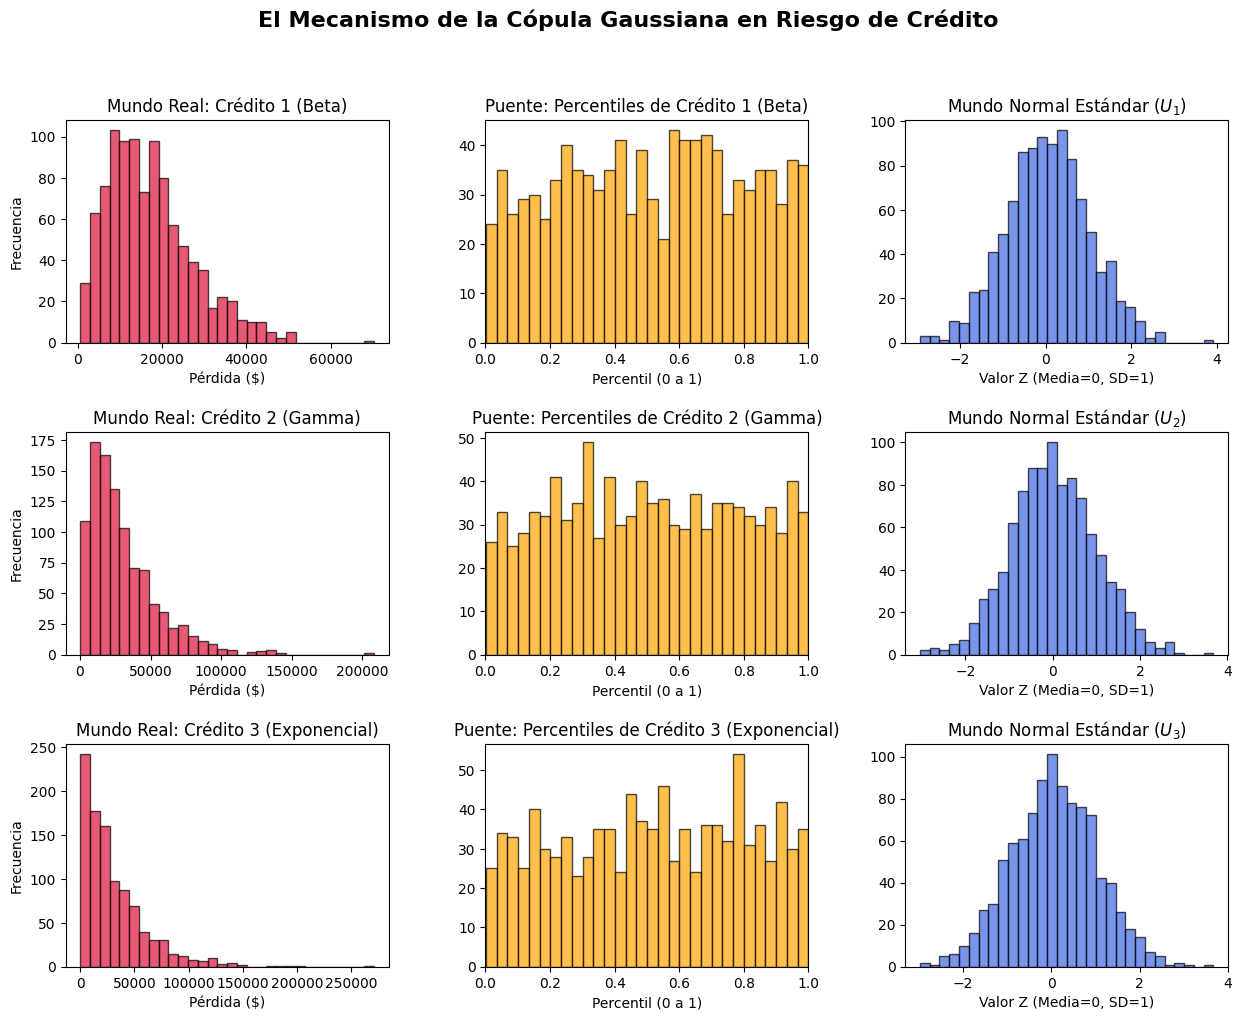

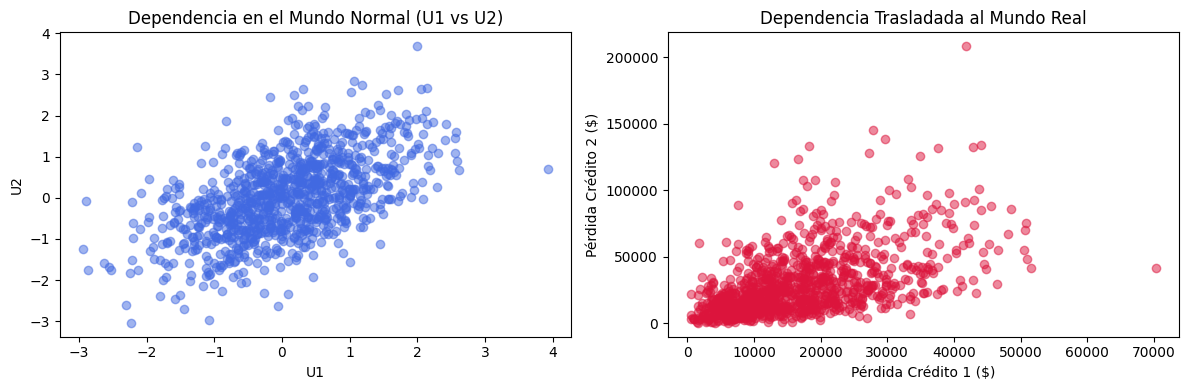

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Configuración de la semilla para reproducibilidad
np.random.seed(42)
n_samples = 1000

# 2. Definir una matriz de correlación para la Cópula (Mundo Normal)
# Tres variables con correlación positiva entre ellas (factores macroeconómicos compartidos)
R = np.array([
    [1.0, 0.6, 0.4],
    [0.6, 1.0, 0.5],
    [0.4, 0.5, 1.0]
])

# 3. Generar datos en el "Mundo Normal" usando la correlación (Variables U_1, U_2, U_3)
# Media 0, varianza 1 para todas (Normal Estándar Multivariada)
L = np.linalg.cholesky(R)
Z = np.random.normal(size=(n_samples, 3))
U_normal = Z @ L.T  # Datos correlacionados en el espacio normal

# 4. PASO CLAVE: Mapear del Mundo Normal a Percentiles (Espacio Uniforme)
# Usamos la Función de Distribución Acumulada (CDF) de la normal estándar
Percentiles = stats.norm.cdf(U_normal)

# 5. PASO CLAVE 2: Mapear los Percentiles a las Distribuciones Marginales Reales
# Definimos 3 tipos de pérdidas de crédito asimétricas y feas (Mundo Real)
# Crédito 1: Distribución Beta (pérdidas concentradas cerca de 0)
Pérdida_Crédito1 = stats.beta.ppf(Percentiles[:, 0], a=2, b=10) * 100000 
# Crédito 2: Distribución Gamma (pérdidas con cola larga a la derecha)
Pérdida_Crédito2 = stats.gamma.ppf(Percentiles[:, 1], a=1.5, scale=20000)
# Crédito 3: Distribución Exponencial
Pérdida_Crédito3 = stats.expon.ppf(Percentiles[:, 2], scale=30000)

# ==================== GRAFICACIÓN ====================
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

nombres_creditos = ["Crédito 1 (Beta)", "Crédito 2 (Gamma)", "Crédito 3 (Exponencial)"]
datos_reales = [Pérdida_Crédito1, Pérdida_Crédito2, Pérdida_Crédito3]

for i in range(3):
    # COLUMNA 1: El Mundo Real (Distribuciones Marginales Asimétricas)
    axes[i, 0].hist(datos_reales[i], bins=30, color='crimson', alpha=0.7, edgecolor='black')
    axes[i, 0].set_title(f"Mundo Real: {nombres_creditos[i]}")
    axes[i, 0].set_xlabel("Pérdida ($)")
    axes[i, 0].set_ylabel("Frecuencia")
    
    # COLUMNA 2: El Puente (Percentiles Puros entre 0 y 1)
    axes[i, 1].hist(Percentiles[:, i], bins=30, color='orange', alpha=0.7, edgecolor='black')
    axes[i, 1].set_title(f"Puente: Percentiles de {nombres_creditos[i]}")
    axes[i, 1].set_xlabel("Percentil (0 a 1)")
    axes[i, 1].set_xlim(0, 1)
    
    # COLUMNA 3: El Mundo Normal (La Cópula Gaussiana)
    axes[i, 2].hist(U_normal[:, i], bins=30, color='royalblue', alpha=0.7, edgecolor='black')
    axes[i, 2].set_title(f"Mundo Normal Estándar ($U_{i+1}$)")
    axes[i, 2].set_xlabel("Valor Z (Media=0, SD=1)")

plt.suptitle("El Mecanismo de la Cópula Gaussiana en Riesgo de Crédito", fontsize=16, fontweight='bold')
plt.show()

# Gráfica adicional para ver la dependencia (La Cópula uniendo las variables)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(U_normal[:, 0], U_normal[:, 1], alpha=0.5, color='royalblue')
plt.title("Dependencia en el Mundo Normal (U1 vs U2)")
plt.xlabel("U1")
plt.ylabel("U2")

plt.subplot(1, 2, 2)
plt.scatter(Pérdida_Crédito1, Pérdida_Crédito2, alpha=0.5, color='crimson')
plt.title("Dependencia Trasladada al Mundo Real")
plt.xlabel("Pérdida Crédito 1 ($)")
plt.ylabel("Pérdida Crédito 2 ($)")
plt.tight_layout()
plt.show()
